# Data Merging Basics

`df_1.merge(df_2, on='column', suffixes=('suffix_1', 'suffix_2'))` : merges two tables based on a shared column `column`
- this is an **inner join**, only returns rows that have matching values in each column
- adds `suffixes` to the shared row to differentiate any columns with the same name
- if you want to merge based on multiple columns you can pass in a list of column names to `on=[list]`

In [6]:
import pandas as pd

df1 = pd.DataFrame({'ID': [1, 2], 'Age': [20, 30], 'Name': ['A', 'B']})
df2 = pd.DataFrame({'ID': [1, 2], 'Age': [25, 35], 'Name': ['C', 'D']})

# Using custom suffixes
merged = pd.merge(df1, df2, on='ID', suffixes=('_left', '_right'))
# Result: Age_left, Age_right, Name_left, Name_right

print(merged)

   ID  Age_left Name_left  Age_right Name_right
0   1        20         A         25          C
1   2        30         B         35          D


- **one-to-one** : every row in the left table is related to only 1 row in the right table
    - For example when considering state populations it makes sense that there would only be 1 value per state in each DataFrame
- **one-to-many** : every row in left table is related to one or more rows in the right table
    - Example : every state would have multiple entries for what industries are in each state
- for one-to-many merging it will just duplicate the row that is in the one category to fit how many entries are in the many

# Merging Tables With Different Join Types

**Left Join** : returns all the values of the left table and only the values of the right table where key columns match
- 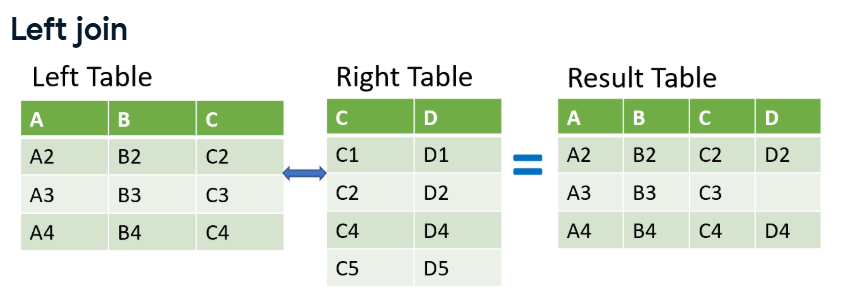
- **syntax**: `df_1.merge(df_2, on=..., how='left')`
- whenever there is a missing value a NaN is added
- a left join will always return the same amount of rows as the left table

You can count the amount of missing (NaN) values using `.isnull().sum()`

**right join** : the same thing as a left join but does it for the table inside the argument
- `.merge(..., how='right')`

You can specify which columns you merge by`.merge()`
- `left_on='col'`
- `'right_on='col'`
so if two differently named columns have the same purposes you can use these arguments to merge them

**Outer Join** : returns all values from both tables
- `.merge(..., how='outer', suffixes=(...))`
- need suffixes to differentiate duplicate data

You can get all the values that are unique to one table using an outer join and then indexes all the rows that contain a NaN

### Merging a table to itself
- you want to merge a table to itself if
    - Hierarchical relationship (employee to manager)
    - Sequential Relationships (logistic moves)
    - Graph data (networks of friend)
- you may want to do this for example to see all the movies that have sequels 
    - `original_sequels = sequels.merge(sequels, left_on='sequel', right_on='id', suffixes=('_org','_seq'))`

### Merging on Indexes
- recall you can create an index column when importing a csv file `pd.read_csv(..., index_col=['col_name'])`
- if both datasets have indexes you can use multi-indexes merges where you pass the names of each index as a list into the `on=['first_id', 'second_id']` argument
    - the returned list has indeces from both lists
    - you can achieve the same results by using `right_on` and `left_on` and the new arguments `left_index=True` and `right_index=True`

# Advanced Merging and Concatenating

### Filtering Joins
- **mutating joins** : combines data from two tables based on matching observations in both tables
- **Filtering Joints** : filter observatino from table based on whether or not they match an observation in another table 
- **Semi-Join** : filters the left table down to any observations that also occur in the right table
    - 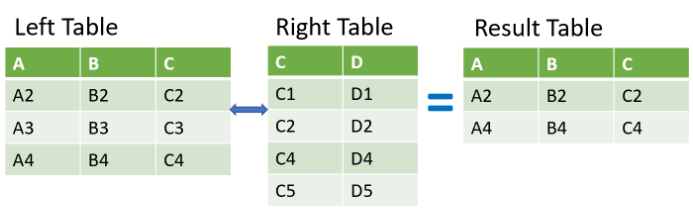
    - similar to an inner join but with only the left columns are perserved
    - no duplicates are returned even if there are a one to many relationship
    - done by
        1. inner join and store in a new DF
        2. use `indeces = df_old['col'].isin(new_df['col'])`
        3. `df_old[indeces]`
- **Anti Join** : returns the left table without the intersection
    - 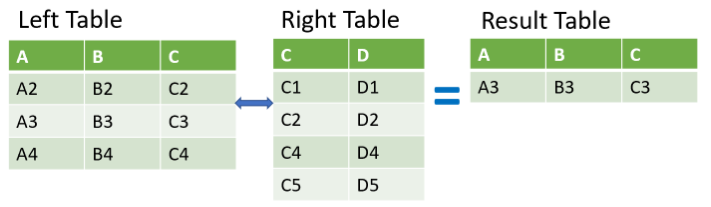
    - steps:
        1. store the left join in a new DF with `indicator=True` in the merge argument
        2. use `new_df.loc[new_df['_LeftSuffix'] == 'left_only', 'col']` and store in as index
        3. `old_df[old_df['col'].isin(index)]`
        


### Concatenate DataFrames Together Vertically
- Basic Concatenation
    - `pd.concat([df_1, df_2, ...])` : will concatenate veritcally in the order they are passed in
    - you an ignore the index by passing in `.ignore_index=True` 
    - you can add labels to see which dataframe it originally came from using the `key=[df_name_1, ...]` agument in `.concat()`
        - ignore index has to to be set to `False`
    - adding `sort=True` will alphabeletically sort the column names in the returned data frame
    - setting the argument `join='inner'` will only returned the shared columns

### Verifying Integrity
- in `.merge(..., validate=None)` you can add the argument validate to check the type of relationship by setting it to the string: 
    * 'one_to_one'
    * 'one_to_many'
    * 'many_to_one'
    * 'many_to_many'
    - if it isn't the relationship passed into the `validate` argument it will **raise an error**
- for `concat(..., verify_integrity=False)` if you set the values to `True` it will check if the concateinated **index** contains duplicates
    - if there is duplicates it will return an error



# Merging Ordered and Time-Series Data

### Using merge_ordered()
- 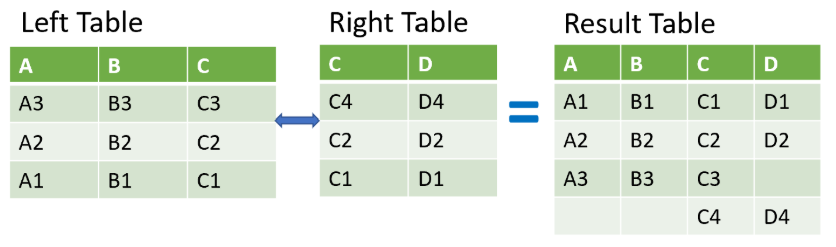
- same as an outerjoin but the results are ordered
- useful for ordered or time series data
- has the arguments
    - `on`, `left_on`, `right_on`
    - `how` (default outer)
    - `suffixes`
- to called `merge_lrdered` you need to call : `pd.merge_ordered(df_1, df_2, ...)`
- **forward fill** : fills all the missing data with the data from the column above it
    - 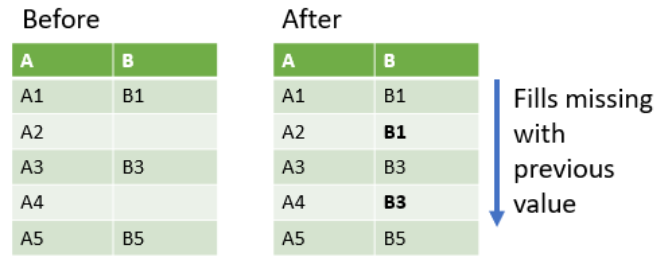
    - if it is the first row it leaves it as NaN
    - done by setting the argument `fill_method='ffill'` in `merge_ordered()`
    - useful as machine learning algorithms require that there are no missing data


### Using merge_asof()
- similar to a `pd.merge_ordered(..., how='left')`
- 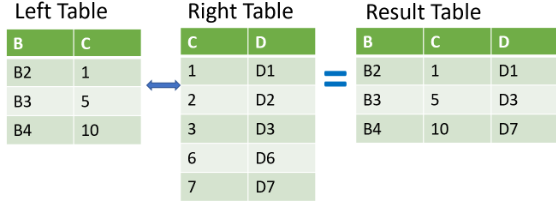
- match on the nearest key column and **not exact matches**
- the `on=...` columns **must be sorted**
- for the argument `direction='forward'` matches each row in the left DataFrame with the first row in the right DataFrame whose key is greater than or equal to the left key
    - `direction='nearest'` will give the nearest value
- you should use when
    - data sampled for a processes where times are similar but not exact
    - developing a training set (no data leakage)

### Selecting Data with .query()
- done by `df.query("...")`
- accepts an input string
- input string used to determine what rows are returned
- similar to the WHERE clause in SQL
- **EX** : `stocks.query('nike >= 90') will return a dataframe only with the rows where nike >= 90
- you can use `and` and `or` keywords
    - if you want to have multiple `and` or `or` statements you have to put them in `()`

### Reshaping Data with .melt()
- unpivot a table from wide to long format which is more eaily worked with with a computer
- 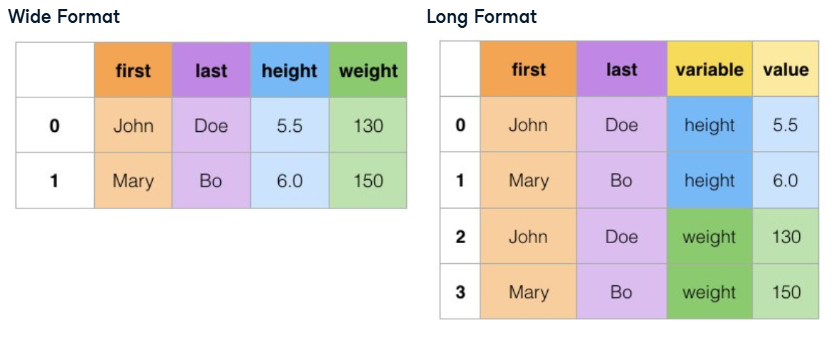
- wide is better for viewing by people 
- **syntax** : `df.melt(id_vars=['col_1', ...])` the columns you do not want to change but instead to use as our IDs
- the argument `value_vars=['col_1', ...]` : specifies what columns you want to unpivot
    - does this in the order you pass it in
- the argument `var_name='name'` changes how the name of the variable column created by `value_vars` is stored as
- similairly `value_name='name'` does the same thing but for the created value column